# 📕 Modul 2: Visualisasi & Storytelling Data (Matplotlib & Seaborn)

**1. Learning Objective**

Mampu memilih jenis visualisasi yang tepat (distribusi, relasi, perbandingan) dan 
merancang grafik yang informatif untuk keperluan analisis data eksploratif (EDA) maupun laporan kepada klien.

**2. Konsep Inti (20% Usaha, 80% Dampak)**

- **Anatomi Plot (`Figure` & `Axes`):** Menggunakan pendekatan berorientasi objek (`fig, ax = plt.subplots()`) agar kontrol layout lebih fleksibel.

- **Distribusi Univariat vs Bivariate:** Kapan menggunakan _Histogram/KDE_ (satu variabel) vs _Scatter Plot/Boxplot_ (dua variabel atau lebih).

- **Seaborn Statistical Plots:** Memanfaatkan kemudahan Seaborn untuk _categorical plots_ (`sns.barplot`, `sns.boxplot`) dan _matrix plots_ (`sns.heatmap`).

---

## Challenge
Buat _correlation heatmap_ dari kolom-kolom numerik pada dataset Melbourne Housing menggunakan `sns.heatmap()`, lalu berikan analisis singkat (1-2 kalimat) mengenai kolom mana yang memiliki korelasi terkuat terhadap `Price`.

## 1. Import Library

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import kagglehub

## 2. Download Dataset & Load Dataset

In [5]:
kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.


'/kaggle/input/melbourne-housing-snapshot'

In [6]:
df = pd.read_csv("/kaggle/input/melbourne-housing-snapshot/melb_data.csv")
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


## 3. Handle Strategy & Detect Missing Value

### ⚠️ Menangani Missing Values

Missing values (NaN) hampir pasti ada di data nyata. Salah menanganinya bisa membuang informasi berharga atau malah menciptakan bias. Aturan pertama: **pahami dulu kenapa datanya hilang, baru putuskan penanganannya.**

#### Tiga Mekanisme Hilangnya Data

- **MCAR** (Missing Completely At Random): hilang murni acak. Paling aman ditangani.
- **MAR** (Missing At Random): hilangnya berkaitan dengan variabel lain (misal: responden muda cenderung tidak mengisi kolom penghasilan).
- **MNAR** (Missing Not At Random): hilangnya berkaitan dengan nilai itu sendiri (misal: orang bergaji tinggi enggan mengisi kolom gaji). Paling berbahaya — imputasi biasa bisa bias.

In [7]:
df_new = df.copy()
df_new

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


### 3.1 Deteksi

- `df.isnull().sum()` — jumlah missing per kolom.
- Persentase lebih informatif daripada jumlah mentah.
- Cek juga **pola**: apakah missing di kolom A selalu barengan kolom B?

In [8]:
jumlah = df_new.isnull().sum()
persen = (df_new.isnull().mean()) * 100
print(pd.DataFrame({"jumlah": jumlah, "persen": persen.round(1)}))

# Baris yang mengandung minimal satu NaN
print("\nBaris dengan NaN:", df_new.isnull().any(axis=1).sum(), "dari", len(df))

               jumlah  persen
Suburb              0     0.0
Address             0     0.0
Rooms               0     0.0
Type                0     0.0
Price               0     0.0
Method              0     0.0
SellerG             0     0.0
Date                0     0.0
Distance            0     0.0
Postcode            0     0.0
Bedroom2            0     0.0
Bathroom            0     0.0
Car                62     0.5
Landsize            0     0.0
BuildingArea     6450    47.5
YearBuilt        5375    39.6
CouncilArea      1369    10.1
Lattitude           0     0.0
Longtitude          0     0.0
Regionname          0     0.0
Propertycount       0     0.0

Baris dengan NaN: 7384 dari 13580


### 3.2 Strategi 1: Hapus (Drop)

- `df.dropna()` — hapus baris yang mengandung NaN.
- `df.dropna(subset=["kolom"])` — hanya jika NaN di kolom tertentu.
- `df.dropna(axis=1, thresh=n)` — hapus kolom yang non-null-nya kurang dari n.

Kapan drop masuk akal: missing-nya sedikit (< 5%) dan MCAR, atau satu kolom bolong parah (> 60-70%) sehingga tidak layak diselamatkan. Hati-hati: drop baris berlebihan = buang informasi + potensi bias.

In [9]:
df_clean = df_new.copy()
print("Sebelum:", df_clean.shape)
print("Kalau dropna semua:", df_clean.dropna().shape)  # kehilangan banyak baris!
print("Drop hanya berdasarkan kolom data:", df_clean.dropna(subset=["BuildingArea"]).shape)

Sebelum: (13580, 21)
Kalau dropna semua: (6196, 21)
Drop hanya berdasarkan kolom data: (7130, 21)


### 3.3 Strategi 2: Imputasi Sederhana

- **Numerik**: isi dengan `median` (tahan outlier) atau `mean` (kalau distribusi normal).
- **Kategorikal**: isi dengan `mode` (nilai terbanyak) atau kategori baru `"Unknown"`.
- **Time series**: `ffill()` (isi dari nilai sebelumnya) / `bfill()`.

Untuk ML: hitung nilai imputasi dari **train set saja**, lalu terapkan ke test set — mencegah data leakage.

In [10]:
df_imp = df_new.copy()

# Numerik -> median
df_imp["Car"] = df_imp["Car"].fillna(df_imp["Car"].median())
df_imp["BuildingArea"] = df_imp["BuildingArea"].fillna(df_imp["BuildingArea"].median())

# Kategorikal -> mode
df_imp["CouncilArea"] = df_imp["CouncilArea"].fillna(df_imp["CouncilArea"].mode()[0])

# Rating -> mean dibulatkan
df_imp["YearBuilt"] = df_imp["YearBuilt"].fillna(df_imp["YearBuilt"].mean().round())

print(df_imp.isnull().sum())
df_imp

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,126.0,1965.0,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,126.0,1965.0,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,126.0,1981.0,Moreland,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,Moreland,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,126.0,1997.0,Moreland,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,Moreland,-37.85908,144.89299,Western Metropolitan,6380.0


### 3.4 Strategi 3: Missing Indicator

Kadang **fakta bahwa data hilang itu sendiri informatif** (terutama MNAR). Solusinya: tambah kolom penanda sebelum imputasi, supaya model tetap tahu baris mana yang aslinya kosong.

In [11]:
df_ind = df_new.copy()
df_ind["car_missing"] = df_ind["Car"].isnull().astype(int)
df_ind["Car"] = df_ind["Car"].fillna(df_ind["Car"].median())
df_ind[["Car", "car_missing"]]

,Car,car_missing
0,1.0,0
1,0.0,0
2,0.0,0
3,1.0,0
4,2.0,0
...,...,...
13575,2.0,0
13576,2.0,0
13577,4.0,0
13578,5.0,0


### 3.5 Strategi Lanjutan (untuk ML)

- `SimpleImputer` (scikit-learn) — imputasi dalam pipeline, aman dari leakage.
- `KNNImputer` — isi berdasarkan baris-baris yang mirip.
- `IterativeImputer` — prediksi nilai hilang dari kolom lain.

#### Rule of Thumb

| Kondisi | Aksi |
|---------|------|
| Missing < 5%, MCAR | Drop baris atau imputasi sederhana |
| Missing 5-30% | Imputasi (median/mode) + pertimbangkan indicator |
| Missing 30-60% | Imputasi hati-hati + indicator, evaluasi kegunaan kolom |
| Missing > 60-70% | Pertimbangkan drop kolom |

## 4. Visualisasi & Storytelling Data

ValueError: Unknown format code 'd' for object of type 'float'

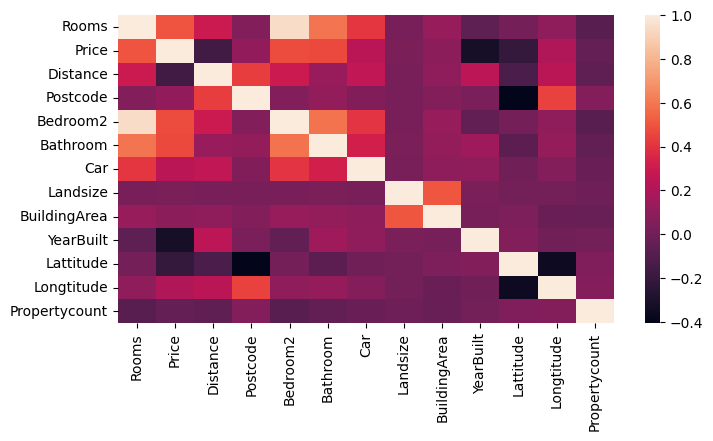

In [ ]:
num_cols = df_clean.select_dtypes(include="number")
corr = num_cols.corr(numeric_only=True)
fig, axs0 = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))

sns.heatmap(corr,ax=axs0, annot=True, fmt=".1f")
plt.ylabel("Correlation")
plt.xlabel("Column")
plt.show()

### 🧠**Analisis berdasarkan korelasi data yang di dapatkan terutama pada kolom data `Price`:**
- Pada korelasi diatas yang terlihat bahwa korelasi yang paling kuat yaitu pada di bagian kolom `Rooms` dengan `Bedroom2`.
- Lalu pada `Price` ada 3 kolom yang sangat lemah korelasinya bahkan ada kolom yang tidak memiliki korelasi sama sekali pada data `Price`.